# Instagram dataset — EDA, cleaning, outlier handling, scaling
This notebook performs exploratory data analysis (visuals & correlations), corrects dtypes, flags and caps outliers (1st/99th percentiles), creates transformed features, and produces two scaled datasets using `StandardScaler` and `RobustScaler`. Artifacts are saved under `../dataset/` and scalers are persisted to `../artifacts/`.
Default choices: cap outliers (keep rows) and persist both scalers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import joblib
from sklearn.preprocessing import StandardScaler, RobustScaler

sns.set(style='whitegrid')
print('pandas', pd.__version__)

pandas 2.2.2


In [3]:
# Paths
ROOT = Path('..')
DATA_DIR = ROOT / 'dataset'
ARTIFACTS = ROOT / 'artifacts'
ARTIFACTS.mkdir(parents=True, exist_ok=True)
IN_PATH = DATA_DIR / 'raw' / 'Instagram.csv'
CLEANED_PATH = DATA_DIR / 'cleaned' / 'Instagram_cleaned.csv'
CLEANED_STD = DATA_DIR / 'cleaned' / 'Instagram_cleaned_scaled_standard.csv'
CLEANED_ROB = DATA_DIR / 'cleaned' / 'Instagram_cleaned_scaled_robust.csv'
SCALER_STD = ARTIFACTS / 'scaler_standard.pkl'
SCALER_ROB = ARTIFACTS / 'scaler_robust.pkl'
df = pd.read_csv(IN_PATH)
df.head()

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake,followers_following_ratio
0,1,0.27,0,0.0,0,53,0,0,32,1000,955,0,1.046025
1,1,0.00,2,0.0,0,44,0,0,286,2740,533,0,5.131086
2,1,0.10,2,0.0,0,0,0,1,13,159,98,0,1.606061
3,1,0.00,1,0.0,0,82,0,0,679,414,651,0,0.634969
4,1,0.00,2,0.0,0,0,0,1,6,151,126,0,1.188976


In [4]:
print('Shape', df.shape)
display(df.describe(include='all').T)
print('Dtypes:')
print(df.dtypes)

Shape (5000, 13)


,count,mean,std,min,25%,50%,75%,max
profile pic,5000.0,0.598200,0.490311,0.0,0.000000,1.000000,1.000000,1.000000e+00
nums/length username,5000.0,0.166175,0.194733,0.0,0.000000,0.089193,0.300410,9.200000e-01
fullname words,5000.0,1.212800,0.890435,0.0,1.000000,1.000000,2.000000,1.200000e+01
nums/length fullname,5000.0,0.036068,0.106235,0.0,0.000000,0.000000,0.000000,1.000000e+00
name==username,5000.0,0.007600,0.086855,0.0,0.000000,0.000000,0.000000,1.000000e+00
description length,5000.0,20.997200,33.234706,0.0,0.000000,1.000000,31.250000,1.500000e+02
external URL,5000.0,0.049600,0.217139,0.0,0.000000,0.000000,0.000000,1.000000e+00
private,5000.0,0.227800,0.419455,0.0,0.000000,0.000000,0.000000,1.000000e+00
#posts,5000.0,103.331400,377.804886,0.0,0.000000,10.000000,81.000000,7.389000e+03
#followers,5000.0,51244.352000,596374.900095,0.0,40.000000,145.000000,696.000000,1.533854e+07


Dtypes:
profile pic                    int64
nums/length username         float64
fullname words                 int64
nums/length fullname         float64
name==username                 int64
description length             int64
external URL                   int64
private                        int64
#posts                         int64
#followers                     int64
#follows                       int64
fake                           int64
followers_following_ratio    float64
dtype: object


In [5]:
rename_map = {
    'profile pic': 'profile_pic',
    'nums/length username': 'username_num_length',
    'fullname words': 'fullname_words',
    'nums/length fullname': 'fullname_num_length',
    'name==username': 'name_eq_username',
    'description length': 'description_length',
    'external URL': 'external_url',
    'private': 'private',
    '#posts': 'num_posts',
    '#followers': 'num_followers',
    '#follows': 'num_follows',
    'fake': 'fake',
    'followers_following_ratio': 'followers_following_ratio'
}
df = df.rename(columns=rename_map)
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
df.columns.tolist()

['profile_pic',
 'username_num_length',
 'fullname_words',
 'fullname_num_length',
 'name_eq_username',
 'description_length',
 'external_url',
 'private',
 'num_posts',
 'num_followers',
 'num_follows',
 'fake',
 'followers_following_ratio']

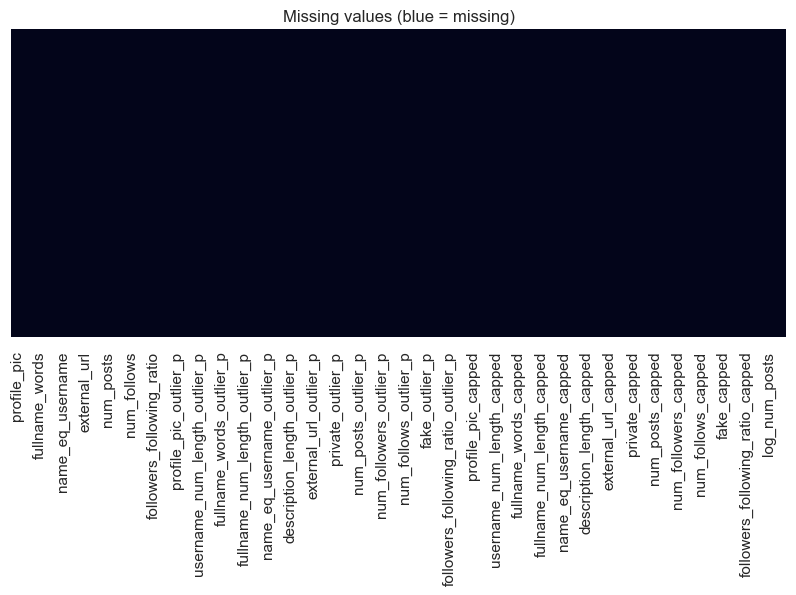

In [19]:
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing values (blue = missing)')
plt.show()

numeric cols: ['profile_pic', 'username_num_length', 'fullname_words', 'fullname_num_length', 'name_eq_username', 'description_length', 'external_url', 'private', 'num_posts', 'num_followers', 'num_follows', 'fake', 'followers_following_ratio']


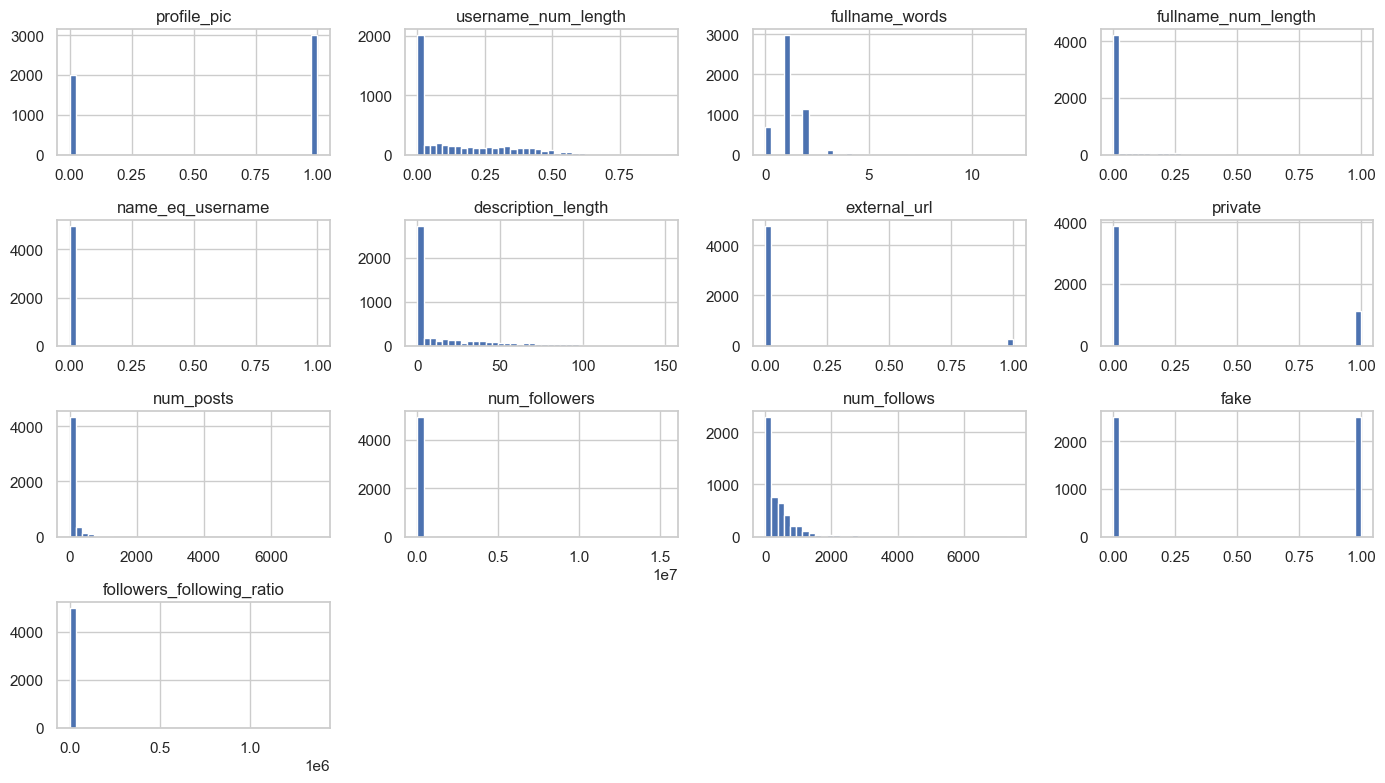

In [7]:
candidate_numeric = ['profile_pic','username_num_length','fullname_words','fullname_num_length',
                     'name_eq_username','description_length','external_url','private',
                     'num_posts','num_followers','num_follows','fake','followers_following_ratio']
numeric_cols = [c for c in candidate_numeric if c in df.columns]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print('numeric cols:', numeric_cols)
df[numeric_cols].hist(bins=40, figsize=(14,8))
plt.tight_layout()
plt.show()

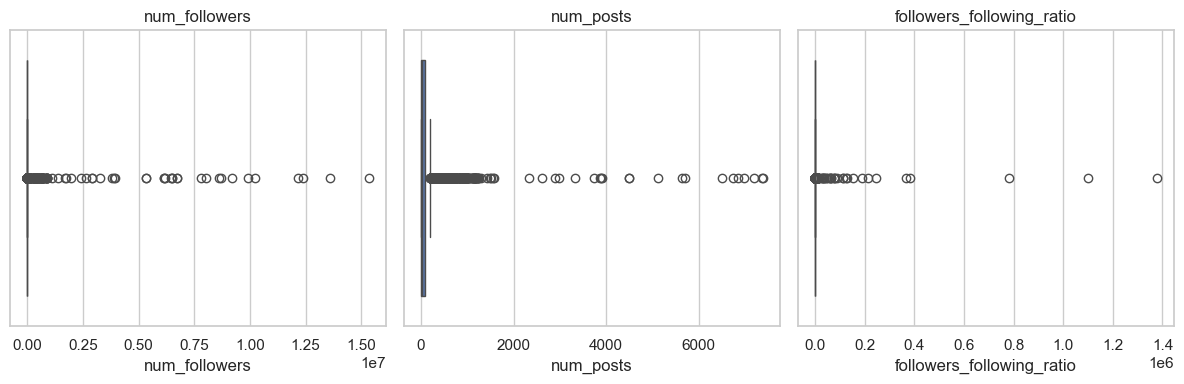

In [8]:
plt.figure(figsize=(12,4))
for i, c in enumerate(['num_followers','num_posts','followers_following_ratio']):
    if c in df.columns:
        plt.subplot(1,3,i+1)
        sns.boxplot(x=df[c].dropna())
        plt.title(c)
plt.tight_layout()
plt.show()

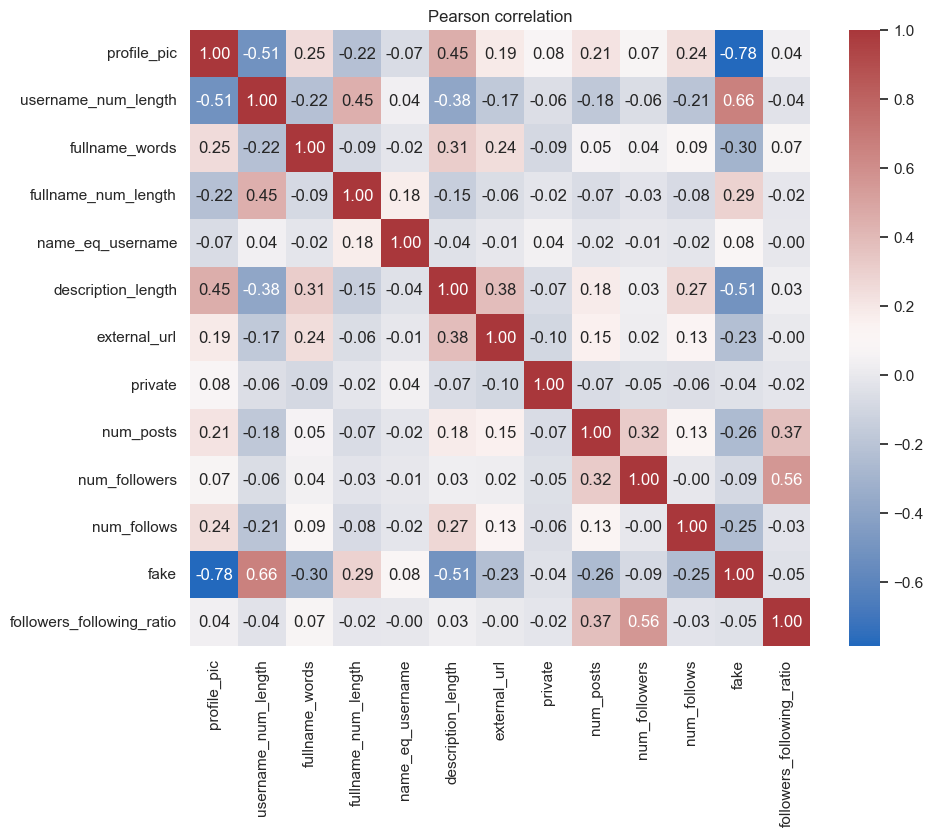

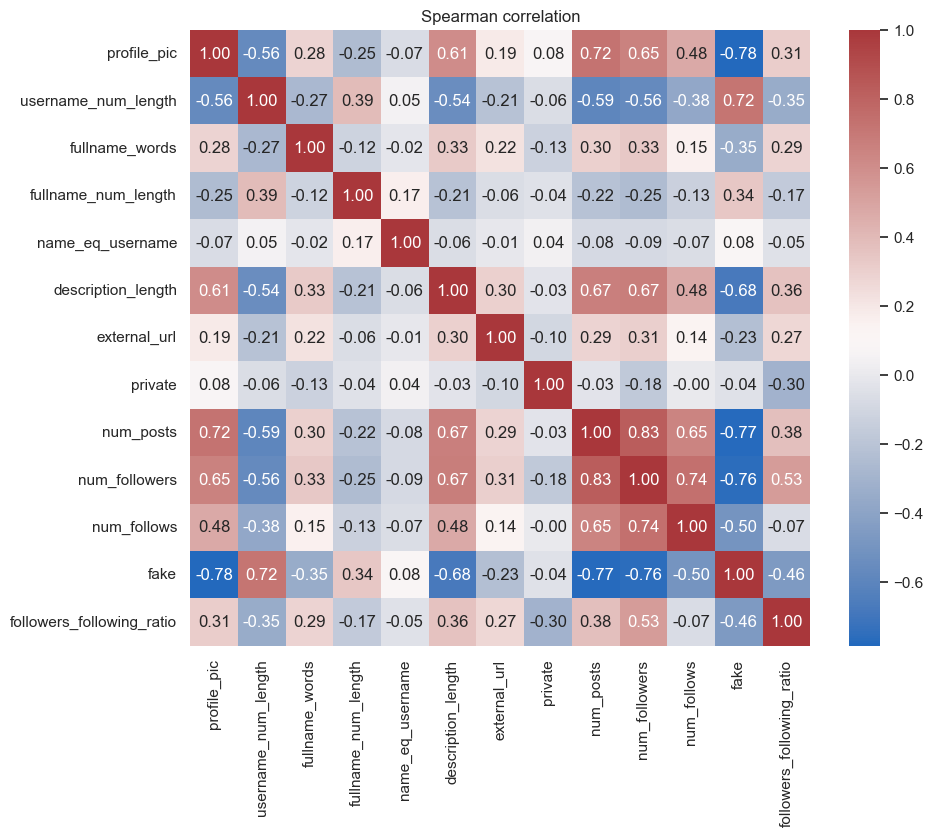

In [9]:
# Correlation matrices (Pearson and Spearman)
corr_features = [c for c in numeric_cols if c in df.columns]
if corr_features:
    plt.figure(figsize=(10,8))
    sns.heatmap(df[corr_features].corr(method='pearson'), annot=True, fmt='.2f', cmap='vlag')
    plt.title('Pearson correlation')
    plt.show()

    plt.figure(figsize=(10,8))
    sns.heatmap(df[corr_features].corr(method='spearman'), annot=True, fmt='.2f', cmap='vlag')
    plt.title('Spearman correlation')
    plt.show()

## Dtype fixes and missing-value strategy
- Convert small integer flags to integer and booleans where appropriate.
- Numeric missing values: median imputation.

In [10]:
# Coerce numeric types again and impute missing numerics with median
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
    df[c] = df[c].fillna(df[c].median())

# Flags as integer/boolean
for flag in ['profile_pic','name_eq_username','external_url','private','fake']:
    if flag in df.columns:
        df[flag] = df[flag].astype(int)

print('Completed dtype fixes and basic imputation')
df[num_cols].dtypes

Completed dtype fixes and basic imputation


profile_pic                    int32
username_num_length          float64
fullname_words                 int64
fullname_num_length          float64
name_eq_username               int32
description_length             int64
external_url                   int32
private                        int32
num_posts                      int64
num_followers                  int64
num_follows                    int64
fake                           int32
followers_following_ratio    float64
dtype: object

## Outlier detection (IQR + percentile) and flags
We add two flags per numeric column: `*_outlier_iqr` (1.5*IQR rule) and `*_outlier_p` (outside 1st/99th percentiles).

In [11]:
outlier_info = {}
for c in num_cols:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1
    lb = q1 - 1.5 * iqr
    ub = q3 + 1.5 * iqr
    p1 = df[c].quantile(0.01)
    p99 = df[c].quantile(0.99)
    outlier_info[c] = dict(iqr_lb=lb, iqr_ub=ub, p1=p1, p99=p99)
    df[c + '_outlier_iqr'] = ((df[c] < lb) | (df[c] > ub)).astype(int)
    df[c + '_outlier_p'] = ((df[c] < p1) | (df[c] > p99)).astype(int)

print('Outlier flags added for', len(num_cols), 'numeric columns')

Outlier flags added for 13 numeric columns


## Capping (winsorizing) at 1st/99th percentiles — non-destructive
We create `_capped` columns and keep originals in `_orig` columns so transformations are reversible.

In [12]:
for c in num_cols:
    p1 = outlier_info[c]['p1']
    p99 = outlier_info[c]['p99']
    df[c + '_orig'] = df[c].copy()
    df[c + '_capped'] = df[c].clip(lower=p1, upper=p99)

print('Applied percentile capping (1st/99th) to numeric columns')

Applied percentile capping (1st/99th) to numeric columns


In [13]:
# Feature engineering: log transforms and ratio clipping
if 'num_followers' in df.columns:
    df['log_num_followers'] = np.log1p(df['num_followers_capped'])
if 'num_posts' in df.columns:
    df['log_num_posts'] = np.log1p(df['num_posts_capped'])
if 'followers_following_ratio' in df.columns:
    cap = df['followers_following_ratio'].quantile(0.999)
    df['followers_following_ratio_clipped'] = df['followers_following_ratio'].clip(upper=cap)

print('Added log transforms and clipped ratio')

Added log transforms and clipped ratio


## Feature scaling
We create two scaled datasets: Standard (mean=0,var=1) and Robust (median/IQR-based). We persist both scalers to `../artifacts/`.
Scale columns: all `_capped` numeric columns plus engineered `log_*` and `*_clipped` features, excluding the `fake` target column.

In [14]:
# Prepare list of columns to scale
scale_candidates = [c + '_capped' for c in num_cols] + [c for c in df.columns if c.startswith('log_') or c.endswith('_clipped')]
# remove duplicates and any target column 'fake'
scale_cols = [c for c in pd.unique(scale_candidates) if c in df.columns and c != 'fake']
print('Scaling columns:', scale_cols)

# Fill any remaining NA in scale columns (should be none)
for c in scale_cols:
    df[c] = df[c].fillna(df[c].median())

# Standard scaler
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(df[scale_cols]) if scale_cols else np.empty((len(df),0))
df_std = df.copy()
for i, c in enumerate(scale_cols):
    df_std[c + '_std'] = X_std[:, i]

# Robust scaler
scaler_rob = RobustScaler()
X_rob = scaler_rob.fit_transform(df[scale_cols]) if scale_cols else np.empty((len(df),0))
df_rob = df.copy()
for i, c in enumerate(scale_cols):
    df_rob[c + '_rob'] = X_rob[:, i]

# Persist scalers
joblib.dump(scaler_std, SCALER_STD)
joblib.dump(scaler_rob, SCALER_ROB)
print('Saved scalers to', SCALER_STD, SCALER_ROB)

Scaling columns: ['profile_pic_capped', 'username_num_length_capped', 'fullname_words_capped', 'fullname_num_length_capped', 'name_eq_username_capped', 'description_length_capped', 'external_url_capped', 'private_capped', 'num_posts_capped', 'num_followers_capped', 'num_follows_capped', 'fake_capped', 'followers_following_ratio_capped', 'log_num_followers', 'log_num_posts', 'followers_following_ratio_clipped']
Saved scalers to ..\artifacts\scaler_standard.pkl ..\artifacts\scaler_robust.pkl


C:\Users\shukl\AppData\Local\Temp\ipykernel_33340\1133362979.py:4: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  scale_cols = [c for c in pd.unique(scale_candidates) if c in df.columns and c != 'fake']


In [15]:
# Save cleaned and scaled CSVs
df.to_csv(CLEANED_PATH, index=False)
df_std.to_csv(CLEANED_STD, index=False)
df_rob.to_csv(CLEANED_ROB, index=False)
print('Saved files:', CLEANED_PATH, CLEANED_STD, CLEANED_ROB)

Saved files: ..\dataset\cleaned\Instagram_cleaned.csv ..\dataset\cleaned\Instagram_cleaned_scaled_standard.csv ..\dataset\cleaned\Instagram_cleaned_scaled_robust.csv
